# ER-Graph 三算法验证 Notebook

这个 Notebook 用于验证 `cd_A` / `cd_B` / `cd_BOmega` 在自动生成 ER 图上的表现，覆盖：

1. 环境与依赖检查
2. 加载待验证对象与测试数据
3. 定义验证规则与评估指标
4. 执行验证流程（批量）
5. 基线对比与回归检查
6. 误差分析与可视化
7. 失败样本定位与日志导出
8. 生成可复用验证报告

In [73]:
# 1) 环境与依赖检查
import os
import sys
import json
import platform
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

print('Python :', sys.version.split()[0])
print('Platform:', platform.platform())
print('numpy  :', np.__version__)
print('pandas :', pd.__version__)

try:
    import sklearn
    print('sklearn:', sklearn.__version__)
except Exception as e:
    print('sklearn not available:', e)

# 仓库根目录加入路径
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if repo_root not in sys.path:
    sys.path.append(repo_root)

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

print('Repo root:', repo_root)

Python : 3.12.3
Platform: Windows-11-10.0.26200-SP0
numpy  : 1.26.4
pandas : 2.2.2
sklearn: 1.5.1
Repo root: c:\Users\super\DAG


In [74]:
# 2) 加载待验证对象与测试数据
from MEC import is_in_markov_equiv_class
from synthetic_dataset import SyntheticDataset
from coordinate_descent.coordinate0 import dag_coordinate_descent_l0_epoch as cd_A
from coordinate_descent.cd_B import dag_coordinate_descent_B_epoch as cd_B
from coordinate_descent.cd_B_Omega import dag_coordinate_descent_BOmega_epoch as cd_BOmega

# 可选：GOLEM-EV / GOLEM-NV
GOLEM_IMPORT_ERROR = None
try:
    golem_src = os.path.join(repo_root, 'golemMain', 'src')
    if golem_src not in sys.path:
        sys.path.append(golem_src)
    from golem import golem as golem_fit
    HAS_GOLEM = True
except Exception as _e:
    HAS_GOLEM = False
    GOLEM_IMPORT_ERROR = _e
    print('GOLEM unavailable, will skip GOLEM-EV/NV:', _e)

# 配置参数（可改）
CFG = {
    'trials': 10,
    'seed': 42,
    'n': 10000,
    'd': 5,
    'degree': 1.0,
    'noise_type': 'gaussian_ev',
    'b_scale': 5.0,
    'threshold': 0.05,
    'k': None,
    'dag_tol': 1e-8,
    'epochs_a': 500,
    'epochs_b': 500,
    'epochs_bomega': 500,
    'lambda_l0': 0.1,
    'tol': 1e-4,
    'patience': 10,
    'min_epochs': 100,
    'eps_omega': 1e-8,

    # GOLEM 参数（用于对比）
    'run_golem': True,
    'golem_num_iter': 20000,
    'golem_learning_rate': 1e-3,
    'golem_lambda1_ev': 2e-2,
    'golem_lambda1_nv': 2e-3,
    'golem_lambda2': 5.0,
}

out_dir = os.path.join(repo_root, 'experiments', 'results')
os.makedirs(out_dir, exist_ok=True)
print('Output dir:', out_dir)
print('HAS_GOLEM:', HAS_GOLEM)
CFG


Output dir: c:\Users\super\DAG\experiments\results
HAS_GOLEM: True


{'trials': 10,
 'seed': 42,
 'n': 10000,
 'd': 5,
 'degree': 1.0,
 'noise_type': 'gaussian_ev',
 'b_scale': 5.0,
 'threshold': 0.05,
 'k': None,
 'dag_tol': 1e-08,
 'epochs_a': 500,
 'epochs_b': 500,
 'epochs_bomega': 500,
 'lambda_l0': 0.1,
 'tol': 0.0001,
 'patience': 10,
 'min_epochs': 100,
 'eps_omega': 1e-08,
 'run_golem': True,
 'golem_num_iter': 20000,
 'golem_learning_rate': 0.001,
 'golem_lambda1_ev': 0.02,
 'golem_lambda1_nv': 0.002,
 'golem_lambda2': 5.0}

In [75]:
# 3) 定义验证规则与评估指标

# 可选：CPDAG-SHD（优先使用 cdt.metrics.SHD_CPDAG，需要 pcalg/R）
try:
    if os.path.join(repo_root, 'toolbox') not in sys.path:
        sys.path.append(os.path.join(repo_root, 'toolbox'))
    from cdt.metrics import SHD_CPDAG as _SHD_CPDAG
    HAS_CPDAG_SHD = True
except Exception as _e:
    _SHD_CPDAG = None
    HAS_CPDAG_SHD = False
    print('CPDAG-SHD backend unavailable, cpdag_shd will be NaN:', _e)


def weight_to_binary_adj(W: np.ndarray, threshold: float) -> np.ndarray:
    G = (np.abs(W) > threshold).astype(int)
    np.fill_diagonal(G, 0)
    return G


def cpdag_shd_score(G_true: np.ndarray, G_est: np.ndarray):
    if not HAS_CPDAG_SHD:
        return np.nan
    try:
        val = _SHD_CPDAG(G_true.astype(int), G_est.astype(int))
        return float(val)
    except Exception:
        return np.nan


def evaluate_algorithm(G_true: np.ndarray, G_est: np.ndarray):
    return {
        'mec_match': int(is_in_markov_equiv_class(G_true, G_est)),
        'exact_match': int(np.array_equal(G_true, G_est)),
        'cpdag_shd': cpdag_shd_score(G_true, G_est),
        'n_edges_true': int(np.sum(G_true)),
        'n_edges_est': int(np.sum(G_est)),
    }

In [ ]:
# 4) 执行验证流程（批量）
from time import perf_counter

rng = np.random.default_rng(CFG['seed'])
seeds = rng.integers(0, 10**9, size=CFG['trials'])

rows = []

# 详细日志：用于失败样本深度分析
detail_logs = []

for t_idx, seed in enumerate(seeds, start=1):
    dataset = SyntheticDataset(
        n=CFG['n'],
        d=CFG['d'],
        graph_type='ER',
        degree=CFG['degree'],
        noise_type=CFG['noise_type'],
        B_scale=CFG['b_scale'],
        seed=int(seed),
    )

    X = dataset.X
    S = X.T @ X / X.shape[0]

    B_true = dataset.B.copy()
    G_true = weight_to_binary_adj(B_true, threshold=0.0)

    # 真实噪声方差/精度（兼容 dataset.N 为标量/1D/2D）
    noise_meta = np.asarray(dataset.N)
    if noise_meta.ndim == 0:
        sigma_true_diag = np.full(CFG['d'], float(noise_meta) ** 2)
    elif noise_meta.ndim == 1:
        if noise_meta.size == CFG['d']:
            sigma_true_diag = np.square(noise_meta.astype(float))
        else:
            sigma_true_diag = np.full(CFG['d'], float(np.mean(noise_meta)) ** 2)
    else:
        sigma_true_diag = np.var(noise_meta, axis=0, ddof=1)

    sigma_true_diag = np.maximum(sigma_true_diag, 1e-12)
    Omega_true_var = np.diag(sigma_true_diag)
    Omega_true_prec = np.diag(1.0 / sigma_true_diag)

    # cd_A (coordinate0 epoch)
    t0 = perf_counter()
    A_est, G_A, obj_A, hist_A = cd_A(
        S=S,
        n_epochs=CFG['epochs_a'],
        seed=int(seed),
        threshold=CFG['threshold'],
        lambda_l0=CFG['lambda_l0'],
        tol=CFG['tol'],
        patience=CFG['patience'],
        min_epochs=CFG['min_epochs'],
        verbose=False,
    )
    t1 = perf_counter()
    m_A = evaluate_algorithm(G_true, G_A)
    m_A.update({'trial': t_idx, 'seed': int(seed), 'algorithm': 'cd_A', 'objective': float(obj_A), 'runtime_sec': t1 - t0, 'epochs_used': len(hist_A)})
    rows.append(m_A)

    detail_logs.append({
        'trial': t_idx,
        'seed': int(seed),
        'algorithm': 'cd_A',
        'objective': float(obj_A),
        'mec_match': m_A['mec_match'],
        'exact_match': m_A['exact_match'],
        'cpdag_shd': m_A['cpdag_shd'],
        'B_true': B_true.copy(),
        'G_true': G_true.copy(),
        'Omega_true_var': Omega_true_var.copy(),
        'Omega_true_prec': Omega_true_prec.copy(),
        'B_est': A_est.copy(),
        'G_est': G_A.copy(),
        'history': hist_A.copy(),
    })

    # cd_B
    t0 = perf_counter()
    B_est, G_B, obj_B, hist_B, _ = cd_B(
        S=S,
        n_epochs=CFG['epochs_b'],
        seed=int(seed),
        threshold=CFG['threshold'],
        lambda_l0=CFG['lambda_l0'],
        k=CFG['k'],
        dag_tol=CFG['dag_tol'],
        tol=CFG['tol'],
        patience=CFG['patience'],
        min_epochs=CFG['min_epochs'],
        verbose=False,
    )
    t1 = perf_counter()
    m_B = evaluate_algorithm(G_true, G_B)
    m_B.update({'trial': t_idx, 'seed': int(seed), 'algorithm': 'cd_B', 'objective': float(obj_B), 'runtime_sec': t1 - t0, 'epochs_used': len(hist_B)})
    rows.append(m_B)

    detail_logs.append({
        'trial': t_idx,
        'seed': int(seed),
        'algorithm': 'cd_B',
        'objective': float(obj_B),
        'mec_match': m_B['mec_match'],
        'exact_match': m_B['exact_match'],
        'cpdag_shd': m_B['cpdag_shd'],
        'B_true': B_true.copy(),
        'G_true': G_true.copy(),
        'Omega_true_var': Omega_true_var.copy(),
        'Omega_true_prec': Omega_true_prec.copy(),
        'B_est': B_est.copy(),
        'G_est': G_B.copy(),
        'history': hist_B.copy(),
    })

    # cd_BOmega
    t0 = perf_counter()
    B_om_est, G_BOm, obj_BOm, hist_BOm, _ = cd_BOmega(
        S=S,
        Omega=np.eye(CFG['d']),
        n_epochs=CFG['epochs_bomega'],
        seed=int(seed),
        threshold=CFG['threshold'],
        lambda_l0=CFG['lambda_l0'],
        k=CFG['k'],
        dag_tol=CFG['dag_tol'],
        tol=CFG['tol'],
        patience=CFG['patience'],
        min_epochs=CFG['min_epochs'],
        eps_omega=CFG['eps_omega'],
        verbose=False,
    )
    t1 = perf_counter()
    m_BOm = evaluate_algorithm(G_true, G_BOm)
    m_BOm.update({'trial': t_idx, 'seed': int(seed), 'algorithm': 'cd_BOmega', 'objective': float(obj_BOm), 'runtime_sec': t1 - t0, 'epochs_used': len(hist_BOm)})
    rows.append(m_BOm)

    detail_logs.append({
        'trial': t_idx,
        'seed': int(seed),
        'algorithm': 'cd_BOmega',
        'objective': float(obj_BOm),
        'mec_match': m_BOm['mec_match'],
        'exact_match': m_BOm['exact_match'],
        'cpdag_shd': m_BOm['cpdag_shd'],
        'B_true': B_true.copy(),
        'G_true': G_true.copy(),
        'Omega_true_var': Omega_true_var.copy(),
        'Omega_true_prec': Omega_true_prec.copy(),
        'B_est': B_om_est.copy(),
        'G_est': G_BOm.copy(),
        'history': hist_BOm.copy(),
    })

    # GOLEM-EV / GOLEM-NV（可选）
    if CFG.get('run_golem', True) and HAS_GOLEM:
        try:
            # GOLEM-EV
            t0 = perf_counter()
            B_golem_ev = golem_fit(
                X,
                lambda_1=CFG['golem_lambda1_ev'],
                lambda_2=CFG['golem_lambda2'],
                equal_variances=True,
                num_iter=CFG['golem_num_iter'],
                learning_rate=CFG['golem_learning_rate'],
                seed=int(seed),
            )
            t1 = perf_counter()
            G_golem_ev = weight_to_binary_adj(B_golem_ev, threshold=CFG['threshold'])
            m_golem_ev = evaluate_algorithm(G_true, G_golem_ev)
            m_golem_ev.update({'trial': t_idx, 'seed': int(seed), 'algorithm': 'golem_ev', 'objective': np.nan, 'runtime_sec': t1 - t0, 'epochs_used': np.nan})
            rows.append(m_golem_ev)

            detail_logs.append({
                'trial': t_idx,
                'seed': int(seed),
                'algorithm': 'golem_ev',
                'objective': np.nan,
                'mec_match': m_golem_ev['mec_match'],
                'exact_match': m_golem_ev['exact_match'],
                'cpdag_shd': m_golem_ev['cpdag_shd'],
                'B_true': B_true.copy(),
                'G_true': G_true.copy(),
                'Omega_true_var': Omega_true_var.copy(),
                'Omega_true_prec': Omega_true_prec.copy(),
                'B_est': B_golem_ev.copy(),
                'G_est': G_golem_ev.copy(),
                'history': [],
            })

            # GOLEM-NV
            t0 = perf_counter()
            B_golem_nv = golem_fit(
                X,
                lambda_1=CFG['golem_lambda1_nv'],
                lambda_2=CFG['golem_lambda2'],
                equal_variances=False,
                num_iter=CFG['golem_num_iter'],
                learning_rate=CFG['golem_learning_rate'],
                seed=int(seed),
            )
            t1 = perf_counter()
            G_golem_nv = weight_to_binary_adj(B_golem_nv, threshold=CFG['threshold'])
            m_golem_nv = evaluate_algorithm(G_true, G_golem_nv)
            m_golem_nv.update({'trial': t_idx, 'seed': int(seed), 'algorithm': 'golem_nv', 'objective': np.nan, 'runtime_sec': t1 - t0, 'epochs_used': np.nan})
            rows.append(m_golem_nv)

            detail_logs.append({
                'trial': t_idx,
                'seed': int(seed),
                'algorithm': 'golem_nv',
                'objective': np.nan,
                'mec_match': m_golem_nv['mec_match'],
                'exact_match': m_golem_nv['exact_match'],
                'cpdag_shd': m_golem_nv['cpdag_shd'],
                'B_true': B_true.copy(),
                'G_true': G_true.copy(),
                'Omega_true_var': Omega_true_var.copy(),
                'Omega_true_prec': Omega_true_prec.copy(),
                'B_est': B_golem_nv.copy(),
                'G_est': G_golem_nv.copy(),
                'history': [],
            })

        except Exception as e:
            print(f"[Trial {t_idx:03d}] GOLEM failed, skip this trial for GOLEM: {e}")

    print(f"Trial {t_idx:03d}/{CFG['trials']} done")


df_results = pd.DataFrame(rows)
df_summary = df_results.groupby('algorithm', as_index=False).agg({
    'mec_match': 'mean',
    'exact_match': 'mean',
    'cpdag_shd': ['mean', 'std'],
    'runtime_sec': ['mean'],
})

# 展平列名
flat_cols = []
for c in df_summary.columns:
    if isinstance(c, tuple):
        a, b = c
        flat_cols.append(a if b == '' else f"{a}_{b}")
    else:
        flat_cols.append(c)
df_summary.columns = flat_cols

print('Results shape:', df_results.shape)
print('Detail logs :', len(detail_logs))
print('HAS_CPDAG_SHD:', HAS_CPDAG_SHD)
print('HAS_GOLEM:', HAS_GOLEM)
display(df_summary)

In [ ]:
# 5) 基线对比与回归检查
# 如果已有历史 summary CSV，则自动对比
baseline_path = os.path.join(out_dir, 'er_cd_benchmark_summary.csv')

if os.path.exists(baseline_path):
    df_base = pd.read_csv(baseline_path)
    # 精简后仅关注：mec_rate / exact_rate / cpdag_shd_mean
    cols_keep = [c for c in ['algorithm', 'mec_rate', 'exact_rate', 'cpdag_shd_mean'] if c in df_base.columns]
    df_base = df_base[cols_keep].copy()

    df_curr = df_summary.copy()
    rename_map = {
        'mec_match_mean': 'mec_rate_curr',
        'exact_match_mean': 'exact_rate_curr',
        'cpdag_shd_mean': 'cpdag_shd_mean_curr',
    }
    for old, new in rename_map.items():
        if old in df_curr.columns:
            df_curr.rename(columns={old: new}, inplace=True)

    df_cmp = pd.merge(df_base, df_curr, on='algorithm', how='inner')

    if 'mec_rate' in df_cmp.columns and 'mec_rate_curr' in df_cmp.columns:
        df_cmp['delta_mec'] = df_cmp['mec_rate_curr'] - df_cmp['mec_rate']
    if 'exact_rate' in df_cmp.columns and 'exact_rate_curr' in df_cmp.columns:
        df_cmp['delta_exact'] = df_cmp['exact_rate_curr'] - df_cmp['exact_rate']
    if 'cpdag_shd_mean' in df_cmp.columns and 'cpdag_shd_mean_curr' in df_cmp.columns:
        df_cmp['delta_cpdag_shd'] = df_cmp['cpdag_shd_mean_curr'] - df_cmp['cpdag_shd_mean']

    # 回归告警规则：MEC 下降超过 0.05 或 CPDAG-SHD 上升超过 0.5
    regressions = pd.DataFrame()
    if 'delta_mec' in df_cmp.columns and 'delta_cpdag_shd' in df_cmp.columns:
        regressions = df_cmp[(df_cmp['delta_mec'] < -0.05) | (df_cmp['delta_cpdag_shd'] > 0.5)]

    print('Loaded baseline:', baseline_path)
    display(df_cmp)
    if len(regressions) > 0:
        print('Regression alerts:')
        display(regressions)
    else:
        print('No regression alerts.')
else:
    df_cmp = None
    regressions = None
    print('No baseline found. Skip regression check.')

No baseline found. Skip regression check.


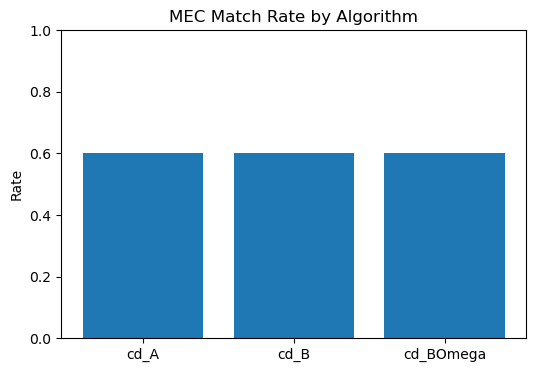

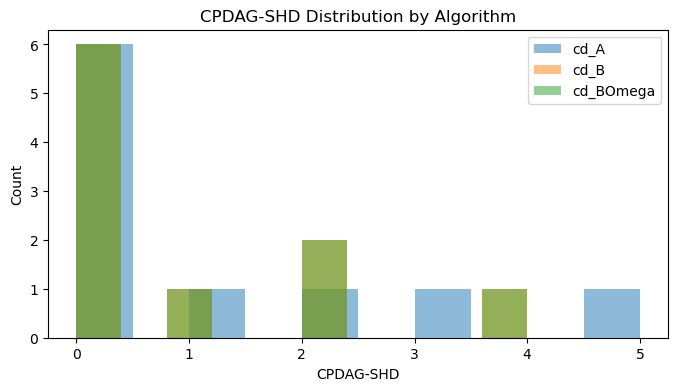

In [ ]:
# 6) 误差分析与可视化（精简版）

# 1) 各算法 MEC 命中率
mec_rates = df_results.groupby('algorithm')['mec_match'].mean().sort_values(ascending=False)
plt.figure(figsize=(6, 4))
plt.bar(mec_rates.index, mec_rates.values)
plt.title('MEC Match Rate by Algorithm')
plt.ylabel('Rate')
plt.ylim(0, 1.0)
plt.show()

# 2) 各算法 CPDAG-SHD 分布（若可用）
if 'cpdag_shd' in df_results.columns and df_results['cpdag_shd'].notna().any():
    plt.figure(figsize=(8, 4))
    for alg in sorted(df_results['algorithm'].unique()):
        vals = df_results.loc[(df_results['algorithm'] == alg) & (df_results['cpdag_shd'].notna()), 'cpdag_shd'].values
        if len(vals) > 0:
            plt.hist(vals, bins=min(10, max(3, len(vals))), alpha=0.5, label=alg)
    plt.title('CPDAG-SHD Distribution by Algorithm')
    plt.xlabel('CPDAG-SHD')
    plt.ylabel('Count')
    plt.legend()
    plt.show()
else:
    print('CPDAG-SHD 不可用（缺少 R/pcalg 或当前结果全为 NaN）。')

In [ ]:
# 7) 失败样本定位与日志导出
# 失败定义：mec_match == 0 或 exact_match == 0
fail_df = df_results[(df_results['mec_match'] == 0) | (df_results['exact_match'] == 0)].copy()

fail_csv = os.path.join(out_dir, 'validate_er_graph_cd_failures.csv')
fail_json = os.path.join(out_dir, 'validate_er_graph_cd_failures.json')

fail_df.to_csv(fail_csv, index=False)
with open(fail_json, 'w', encoding='utf-8') as f:
    json.dump(fail_df.to_dict(orient='records'), f, ensure_ascii=False, indent=2)

print('Failure count:', len(fail_df))
print('Saved:', fail_csv)
print('Saved:', fail_json)
display(fail_df.head(20))

# ---------- 打印失败样本的详细矩阵信息 ----------
TARGET_ALG = None      # 例如 'cd_A' / 'cd_B' / 'cd_BOmega'；None 表示不过滤
MAX_PRINT = 5          # 最多打印多少个失败样本

detail_map = {(x['trial'], x['algorithm']): x for x in detail_logs}

# 优先按 CPDAG-SHD（若可用）排序，否则按 trial
if 'cpdag_shd' in fail_df.columns:
    failed_cases = fail_df.copy()
    failed_cases['_sort_cpdag'] = failed_cases['cpdag_shd'].fillna(-1)
    failed_cases = failed_cases.sort_values(by=['_sort_cpdag', 'trial'], ascending=[False, True]).drop(columns=['_sort_cpdag'])
else:
    failed_cases = fail_df.sort_values(by=['trial'], ascending=[True]).copy()

if TARGET_ALG is not None:
    failed_cases = failed_cases[failed_cases['algorithm'] == TARGET_ALG]

failed_cases = failed_cases.head(MAX_PRINT)

if len(failed_cases) == 0:
    print('没有符合条件的失败样本可打印。')
else:
    print(f'准备打印 {len(failed_cases)} 个失败样本详细信息...')

for _, r in failed_cases.iterrows():
    key = (int(r['trial']), r['algorithm'])
    info = detail_map.get(key, None)
    if info is None:
        continue

    print('\n' + '=' * 90)
    cpdag_val = info.get('cpdag_shd', np.nan)
    cpdag_txt = 'NaN' if pd.isna(cpdag_val) else f"{cpdag_val:.3f}"
    print(f"Trial={info['trial']} | Seed={info['seed']} | Alg={info['algorithm']}")
    print(f"Objective={info['objective']:.6f} | CPDAG-SHD={cpdag_txt} | MEC={info['mec_match']} | Exact={info['exact_match']}")
    print('-' * 90)

    print('B_true:')
    print(np.array2string(info['B_true'], precision=3, suppress_small=True))

    print('\nOmega_true (variance diag matrix):')
    print(np.array2string(info['Omega_true_var'], precision=3, suppress_small=True))

    print('\nOmega_true (precision diag matrix):')
    print(np.array2string(info['Omega_true_prec'], precision=3, suppress_small=True))

    print('\nB_est:')
    print(np.array2string(info['B_est'], precision=3, suppress_small=True))

    print('\nG_true:')
    print(info['G_true'])

    print('\nG_est:')
    print(info['G_est'])

Failure count: 12
Saved: c:\Users\super\DAG\experiments\results\validate_er_graph_cd_failures.csv
Saved: c:\Users\super\DAG\experiments\results\validate_er_graph_cd_failures.json


,mec_match,exact_match,cpdag_shd,n_edges_true,n_edges_est,trial,seed,algorithm,objective,runtime_sec,epochs_used
0,0,0,5.0,4,7,1,89250953,cd_A,5.044075,1.135693,123
1,0,0,4.0,4,6,1,89250953,cd_B,0.032073,0.696041,109
2,0,0,4.0,4,6,1,89250953,cd_BOmega,2.516037,0.755967,109
6,0,0,1.0,2,3,3,654571518,cd_A,5.010971,0.930206,109
7,0,0,1.0,2,1,3,654571518,cd_B,0.050155,0.763835,109
8,0,0,1.0,2,1,3,654571518,cd_BOmega,2.525078,0.803830,109
12,0,0,2.0,2,2,5,433015235,cd_A,5.342477,0.947805,109
13,0,0,2.0,2,2,5,433015235,cd_B,0.342477,0.751159,109
14,0,0,2.0,2,2,5,433015235,cd_BOmega,2.671238,0.861663,109
21,0,0,3.0,4,3,8,94177347,cd_A,9.605860,0.892751,109


准备打印 5 个失败样本详细信息...

Trial=1 | Seed=89250953 | Alg=cd_A
Objective=5.044075 | CPDAG-SHD=5.000 | MEC=0 | Exact=0
------------------------------------------------------------------------------------------
B_true:
[[ 0.     0.     0.     0.     0.   ]
 [ 4.873  0.     0.     0.     0.   ]
 [ 6.444  0.     0.     0.    -6.063]
 [ 0.     0.     0.     0.     0.   ]
 [ 0.     0.     0.    -8.067  0.   ]]

Omega_true (variance diag matrix):
[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]

Omega_true (precision diag matrix):
[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]

B_est:
[[ 0.692  0.    -0.643  0.     0.   ]
 [-3.368  0.986  3.119  0.     0.   ]
 [ 0.     0.     8.412  0.     0.   ]
 [ 0.     0.    -0.054  1.     0.   ]
 [ 0.718  0.     0.249  8.064  0.163]]

G_true:
[[0 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 1]
 [0 0 0 0 0]
 [0 0 0 1 0]]

G_est:
[[0 0 1 0 0]
 [1 0 1 0 0]
 [0 0 0 0 0]
 [0 0 1 0 0]
 [1 0 1 1 

In [ ]:
# 8) 生成可复用验证报告
now_str = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
report_path = os.path.join(out_dir, 'validate_er_graph_cd_report.md')
summary_csv = os.path.join(out_dir, 'validate_er_graph_cd_summary.csv')
trial_csv = os.path.join(out_dir, 'validate_er_graph_cd_trials.csv')

df_summary.to_csv(summary_csv, index=False)
df_results.to_csv(trial_csv, index=False)

lines = []
lines.append('# ER-Graph Validation Report\n')
lines.append(f'- Generated at: {now_str}')
lines.append(f"- Trials: {CFG['trials']}, n={CFG['n']}, d={CFG['d']}, degree={CFG['degree']}")
lines.append(f"- Noise: {CFG['noise_type']}, threshold={CFG['threshold']}, lambda_l0={CFG['lambda_l0']}\n")

lines.append('## Summary (mean metrics)\n')
lines.append(df_summary.to_markdown(index=False))
lines.append('\n\n## Failure stats\n')
lines.append(f'- Failure count: {len(fail_df)}')
lines.append(f'- Failure CSV: {fail_csv}')
lines.append(f'- Failure JSON: {fail_json}')

if 'regressions' in globals() and regressions is not None and len(regressions) > 0:
    lines.append('\n\n## Regression alerts\n')
    lines.append(regressions.to_markdown(index=False))

with open(report_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))

print('Saved trial CSV :', trial_csv)
print('Saved summary CSV:', summary_csv)
print('Saved report     :', report_path)
report_path

Saved trial CSV : c:\Users\super\DAG\experiments\results\validate_er_graph_cd_trials.csv
Saved summary CSV: c:\Users\super\DAG\experiments\results\validate_er_graph_cd_summary.csv
Saved report     : c:\Users\super\DAG\experiments\results\validate_er_graph_cd_report.md


'c:\\Users\\super\\DAG\\experiments\\results\\validate_er_graph_cd_report.md'